<a href="https://colab.research.google.com/github/avicohen38/animated-winner/blob/main/Assignment1EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# הגדרות עיצוב כלליות לגרפים
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


<div dir="rtl">

## 2. בחירת מערך נתונים ותיאור המקור

* **מקור הנתונים:** מערך הנתונים "Power Consumption of Tetouan City" הורד מפלטפורמת Kaggle.
* **מטרת האיסוף:** הנתונים נאספו כדי לחקור ולנתח את צריכת החשמל באזורים שונים בעיר טטואן בהתאם לתנאי מזג האוויר המשתנים.
* **הגורם האוסף:** רשת החשמל של העיר טטואן (מרוקו) או חוקרים שאספו את הנתונים מהרשת.
* **קשר לתחום:** הבנת דפוסי צריכת חשמל ביחס למשתנים מטאורולוגיים היא קריטית לניהול עומסים ברשתות חשמל חכמות (Smart Grids) ולחיזוי ביקושים עתידיים.

</div>

In [ ]:
# קריאת קובץ הנתונים (/content/Tetuan City power consumption.csv.zip)
df = pd.read_csv('/content/Tetuan City power consumption.csv.zip')

# הצגת 5 השורות הראשונות כדי לוודא שהכל נטען כמו שצריך
df.head()

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [ ]:
# 1. המרת עמודת התאריך לסוג נתונים מיוחד של זמן
df['DateTime'] = pd.to_datetime(df['DateTime'])

# 2. הנדסת מאפיינים (Feature Engineering) - יצירת עמודות חדשות
df['Month'] = df['DateTime'].dt.month        # חודש
df['Hour'] = df['DateTime'].dt.hour          # שעה ביום
df['Is_Weekend'] = df['DateTime'].dt.dayofweek >= 5  # האם זה סוף שבוע? (True/False)

# 3. הצגת מידע על הטבלה כדי לוודא שעכשיו יש לנו מספיק עמודות וסוגי נתונים שונים
print("Dataset Info:")
df.info()

print("\nFirst 5 rows:")
df.head()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   DateTime                   52416 non-null  datetime64[ns]
 1   Temperature                52416 non-null  float64       
 2   Humidity                   52416 non-null  float64       
 3   Wind Speed                 52416 non-null  float64       
 4   general diffuse flows      52416 non-null  float64       
 5   diffuse flows              52416 non-null  float64       
 6   Zone 1 Power Consumption   52416 non-null  float64       
 7   Zone 2  Power Consumption  52416 non-null  float64       
 8   Zone 3  Power Consumption  52416 non-null  float64       
 9   Month                      52416 non-null  int32         
 10  Hour                       52416 non-null  int32         
 11  Is_Weekend                 52416 non-null  bool      

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption,Month,Hour,Is_Weekend
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,1,0,True
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,1,0,True
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,1,0,True
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,1,0,True
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,1,0,True


<div dir="rtl">

## 3. מטא-אנליזה של הנתונים

### 3.1 ניתוח הקובץ
* **גודל הקובץ:** כ-4.0 MB בזיכרון.
* **פורמט:** קובץ טבלאי מסוג CSV.
* **מטרת הנתונים:** הנתונים נועדו למדוד צריכת חשמל ב-3 אזורים שונים בעיר במקביל לנתוני מזג האוויר, ככל הנראה לטובת חיזוי או מחקר אנרגטי.

### 3.2 מבנה הנתונים
* **מספר שורות ועמודות:** 52,416 שורות ו-12 עמודות (הגענו ל-12 עמודות לאחר ביצוע הנדסת מאפיינים ופירוק עמודת הזמן).
* **שמות העמודות:** השמות באנגלית ברורים והגיוניים (Temperature, Humidity, Zone 1 Power Consumption וכו'). ניתן ללמוד מהם שהמידע משלב מדידות מטאורולוגיות רציפות יחד עם נתוני צריכת חשמל.
* **סוגי נתונים:** שילוב של ערכים מספריים רציפים (`float64`) למדידות, ערכי תאריך/זמן (`datetime64`) למעקב כרונולוגי, ערכים שלמים (`int32`) עבור שעה וחודש, וערך בוליאני (`bool`) לציון האם מדובר בסוף שבוע. סוגי הנתונים תקינים לחלוטין.
* **ניתוח אינדקס:** האינדקס הוא מספרי רגיל מ-0 עד 52,415. הוא ייחודי אך חסר משמעות בפני עצמו (לא מייצג ת.ז למשל), שכן המשמעות והסדר של הנתונים נובעים מעמודת ה-DateTime.
* **הטיות אפשריות (דיון):** הנתונים נאספו ככל הנראה לצורך תפעול רשת החשמל ומחקר. הטיה אפשרית יכולה לנבוע ממיקום ספציפי של החיישנים המטאורולוגיים שאולי לא מייצג את המיקרו-אקלים בכל רחבי העיר, או מכך שהאזורים המדודים (Zones) מאופיינים באוכלוסייה מסוימת או בתעשייה שאינה בהכרח מייצגת עיר ממוצעת.

</div>

In [ ]:
print("--- 4.1 Missing Values (נתונים חסרים) ---")
# בדיקה כמה ערכים חסרים (NaN) יש בכל עמודה
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])
if missing_values.sum() == 0:
    print("אין נתונים חסרים בקובץ!")

print("\n--- 4.2 Duplicates (כפילויות) ---")
# בדיקת שורות כפולות במדויק
duplicate_rows = df.duplicated().sum()
print(f"מספר שורות כפולות (זהות לחלוטין): {duplicate_rows}")

print("\n--- 4.3 Suspicious Values (ערכים חשודים) ---")
# המטרה כאן היא לבדוק אם יש ערכים בלתי אפשריים (למשל, צריכת חשמל או לחות מתחת לאפס)
numeric_cols = ['Temperature', 'Humidity', 'Wind Speed', 'Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption']

for col in numeric_cols:
    min_val = df[col].min()
    max_val = df[col].max()
    print(f"{col}: Min = {min_val:.2f}, Max = {max_val:.2f}")

    # בדיקה ספציפית לערכים שליליים איפה שלא אמורים להיות
    if min_val < 0 and col != 'Temperature':
         print(f"  -> אזהרה: נמצאו ערכים שליליים בעמודת {col}!")

print("\n--- 4.4 Cardinality (קרדינליות) ---")
# בדיקה כמה ערכים ייחודיים יש בכל עמודה
print(df.nunique())

--- 4.1 Missing Values (נתונים חסרים) ---
Series([], dtype: int64)
אין נתונים חסרים בקובץ!

--- 4.2 Duplicates (כפילויות) ---
מספר שורות כפולות (זהות לחלוטין): 0

--- 4.3 Suspicious Values (ערכים חשודים) ---
Temperature: Min = 3.25, Max = 40.01
Humidity: Min = 11.34, Max = 94.80
Wind Speed: Min = 0.05, Max = 6.48
Zone 1 Power Consumption: Min = 13895.70, Max = 52204.40
Zone 2  Power Consumption: Min = 8560.08, Max = 37408.86
Zone 3  Power Consumption: Min = 5935.17, Max = 47598.33

--- 4.4 Cardinality (קרדינליות) ---
DateTime                     52416
Temperature                   3437
Humidity                      4443
Wind Speed                     548
general diffuse flows        10504
diffuse flows                10449
Zone 1 Power Consumption     27709
Zone 2  Power Consumption    29621
Zone 3  Power Consumption    22838
Month                           12
Hour                            24
Is_Weekend                       2
dtype: int64


<div dir="rtl">

## 4. איכות ושלמות הנתונים

### 4.1 נתונים חסרים
* **היקף ודפוס:** לא נמצאו כלל נתונים חסרים (0 ערכי NaN) באף אחת מהעמודות.
* **מסקנות:** מכיוון שאין נתונים חסרים, ניתן להסיק שהמידע נאסף ממערכת חיישנים אמינה ורציפה או שהקובץ עבר תהליך ניקוי קפדני בטרם פורסם. אין צורך להפעיל שיטות להשלמת נתונים חסרים.

### 4.2 כפילויות
* בבדיקה לא נמצאו כלל שורות כפולות (זהות לחלוטין). הדבר מעיד על איכות נתונים גבוהה ומונע הטיות בניתוח הסטטיסטי שלנו. לא נדרשת פעולת מחיקה.

### 4.3 ערכים חשודים
* בבחינת ערכי הקיצון (Max/Min), לא נמצאו ערכים בלתי אפשריים או שגיאות הקלדה. צריכת החשמל ומהירות הרוח מציגות ערכים חיוביים בלבד. טווחי הטמפרטורה (3.25 עד 40.01 מעלות צלזיוס) והלחות (11.34% עד 94.80%) הגיוניים לחלוטין לעיר באקלים הנבדק.

### 4.4 קרדינליות
* אין במערך הנתונים עמודות ללא שונות (בעלות ערך בודד).
* **תובנות מהקרדינליות:** עמודת ה-DateTime מכילה 52,416 ערכים ייחודיים – בדיוק כמספר השורות. המשמעות היא שכל שורה מתעדת חותמת זמן ייחודית ומדויקת. בנוסף, משתני הזמן מציגים קרדינליות מושלמת שמייצגת את המציאות: 12 ערכים לעמודת החודש, 24 ערכים לעמודת השעות, ו-2 ערכים (True/False) לעמודת סוף השבוע.

</div>

In [ ]:
print("--- 5.1 משתנים מספריים (סטטיסטיקה תיאורית) ---")
# יצירת רשימה של העמודות המספריות הרלוונטיות
numeric_cols = ['Temperature', 'Humidity', 'Wind Speed', 'Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption']

# חישוב הסטטיסטיקות (ממוצע, סטיית תקן, מינימום, מקסימום, רבעונים)
desc_stats = df[numeric_cols].describe()

# הוספת חציון (שזה בעצם האחוזון ה-50 שכבר מחושב ב-describe, אבל נציג אותו בנפרד ליתר ביטחון)
desc_stats.loc['median'] = df[numeric_cols].median()

# הצגת התוצאות
display(desc_stats)

print("\n--- 5.2 משתנים קטגוריאליים (שכיחויות) ---")
# בדאטה שלנו, העמודות שיצרנו (Month, Hour, Is_Weekend) מתפקדות כקטגוריאליות
cat_cols = ['Month', 'Hour', 'Is_Weekend']

for col in cat_cols:
    print(f"\nשכיחויות עבור עמודת: {col}")
    # חישוב השכיחות וגם את האחוז היחסי מתוך כלל הנתונים
    value_counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100

    # שילוב לתוך DataFrame להצגה יפה
    freq_table = pd.DataFrame({'Count': value_counts, 'Percentage (%)': percentages})
    display(freq_table.head()) # נציג רק את ה-5 הראשונים כדי לא להעמיס על המסך

--- 5.1 משתנים מספריים (סטטיסטיקה תיאורית) ---


,Temperature,Humidity,Wind Speed,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
count,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000
mean,18.810024,68.259518,1.959489,32344.970564,21042.509082,17835.406218
std,5.815476,15.551177,2.348862,7130.562564,5201.465892,6622.165099
min,3.247000,11.340000,0.050000,13895.696200,8560.081466,5935.174070
25%,14.410000,58.310000,0.078000,26310.668692,16980.766032,13129.326630
50%,18.780000,69.860000,0.086000,32265.920340,20823.168405,16415.117470
75%,22.890000,81.400000,4.915000,37309.018185,24713.717520,21624.100420
max,40.010000,94.800000,6.483000,52204.395120,37408.860760,47598.326360
median,18.780000,69.860000,0.086000,32265.920340,20823.168405,16415.117470



--- 5.2 משתנים קטגוריאליים (שכיחויות) ---

שכיחויות עבור עמודת: Month


,Count,Percentage (%)
Month,,
1,4464,8.516484
3,4464,8.516484
7,4464,8.516484
5,4464,8.516484
8,4464,8.516484



שכיחויות עבור עמודת: Hour


,Count,Percentage (%)
Hour,,
0,2184,4.166667
1,2184,4.166667
2,2184,4.166667
3,2184,4.166667
4,2184,4.166667



שכיחויות עבור עמודת: Is_Weekend


,Count,Percentage (%)
Is_Weekend,,
False,37440,71.428571
True,14976,28.571429


In [ ]:
import numpy as np
from scipy.stats import zscore

print("--- 5.1 מציאת חריגים ב-3 שיטות שונות ---")

# נתמקד בעמודות הרלוונטיות של המדידות הרציפות
cols_to_check = ['Temperature', 'Humidity', 'Wind Speed', 'Zone 1 Power Consumption']

for col in cols_to_check:
    print(f"\nבודק חריגים בעמודה: {col}")

    # שיטה 1: Z-Score (ערכים שרחוקים יותר מ-3 סטיות תקן מהממוצע)
    z_scores = np.abs(zscore(df[col]))
    outliers_z = (z_scores > 3).sum()

    # שיטה 2: IQR (טווח בין רבעוני)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_iqr = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

    # שיטה 3: MAD (Median Absolute Deviation) - סטייה מוחלטת מהחציון
    median = df[col].median()
    mad = np.abs(df[col] - median).median()
    # ערך נחשב חריג אם הוא רחוק יותר מ-3 פעמים ה-MAD (מותאם להתפלגות נורמלית עם פקטור 1.4826)
    outliers_mad = (np.abs(df[col] - median) > (3 * mad * 1.4826)).sum()

    print(f"  > חריגים לפי Z-Score: {outliers_z}")
    print(f"  > חריגים לפי IQR: {outliers_iqr}")
    print(f"  > חריגים לפי MAD: {outliers_mad}")

--- 5.1 מציאת חריגים ב-3 שיטות שונות ---

בודק חריגים בעמודה: Temperature
  > חריגים לפי Z-Score: 89
  > חריגים לפי IQR: 142
  > חריגים לפי MAD: 37

בודק חריגים בעמודה: Humidity
  > חריגים לפי Z-Score: 209
  > חריגים לפי IQR: 291
  > חריגים לפי MAD: 123

בודק חריגים בעמודה: Wind Speed
  > חריגים לפי Z-Score: 0
  > חריגים לפי IQR: 0
  > חריגים לפי MAD: 22304

בודק חריגים בעמודה: Zone 1 Power Consumption
  > חריגים לפי Z-Score: 0
  > חריגים לפי IQR: 0
  > חריגים לפי MAD: 0


<div dir="rtl">

## 5. ניתוח חד-משתני

### 5.1 משתנים מספריים
* **מדדים מרכזיים והתפלגות:** בבחינת הסטטיסטיקה התיאורית, ניתן לראות כי משתני הטמפרטורה והלחות מתפלגים בצורה כמעט סימטרית, שכן הממוצע והחציון שלהם כמעט זהים (למשל טמפרטורה: ממוצע 18.81, חציון 18.78).
* **הטייה (Skewness):** לעומת זאת, משתנה מהירות הרוח (Wind Speed) מציג הטייה חזקה ימינה - הממוצע שלו (1.95) גדול בהרבה מהחציון (0.086). רוב הזמן הרוח חלשה מאוד, אך קפיצות פתאומיות מושכות את הממוצע כלפי מעלה.

### 5.2 משתנים קטגוריאליים (זמן)
* **שכיחויות:** המשתנים הקטגוריאליים (שנגזרו ממשתני הזמן) מראים התפלגות אחידה ומושלמת. כל חודש תופס בדיוק 8.51% מהנתונים, וכל שעה תופסת בדיוק 4.16% מהנתונים. דבר זה מוכיח רציפות מוחלטת במדידה ללא הפסקות או "חורים".
* חלוקת ימי חול מול סוף שבוע עומדת על 71.4% (ימי חול) לעומת 28.5% (סופ"ש), מה שתואם במדויק את יחס הימים הקלנדרי (5 ימים מתוך 7).

### 5.3 מציאת חריגים (Outliers)
חיפוש החריגים בוצע ב-3 שיטות שונות (Z-Score, IQR, MAD):
1. **טמפרטורה ולחות:** נמצאה כמות הגיונית של חריגים קלים. שיטת ה-IQR הייתה הרגישה ביותר (291 חריגים בלחות), בעוד ש-MAD ו-Z-Score היו שמרניות יותר.
2. **אזור צריכה 1:** לא נמצאו חריגים באף אחת מהשיטות, מה שמעיד על צריכה יציבה יחסית ללא זינוקים קיצוניים למעלה או למטה.
3. **תובנה מעניינת - מהירות הרוח:** בעוד ש-Z-Score ו-IQR לא מצאו חריגים כלל (0), שיטת ה-MAD זיהתה 22,304 חריגים! הסיבה לכך היא שהחציון קרוב מאוד לאפס והפיזור סביבו מזערי, כך שכל שינוי קל ברוח נחשב מתמטית כסטייה חריגה מוחלטת מהחציון. זה מדגיש ששיטת MAD לא תמיד מתאימה למשתנים בעלי שונות אפסית כמעט.

</div>

--- 6.1 קורלציות בין משתנים מספריים ---


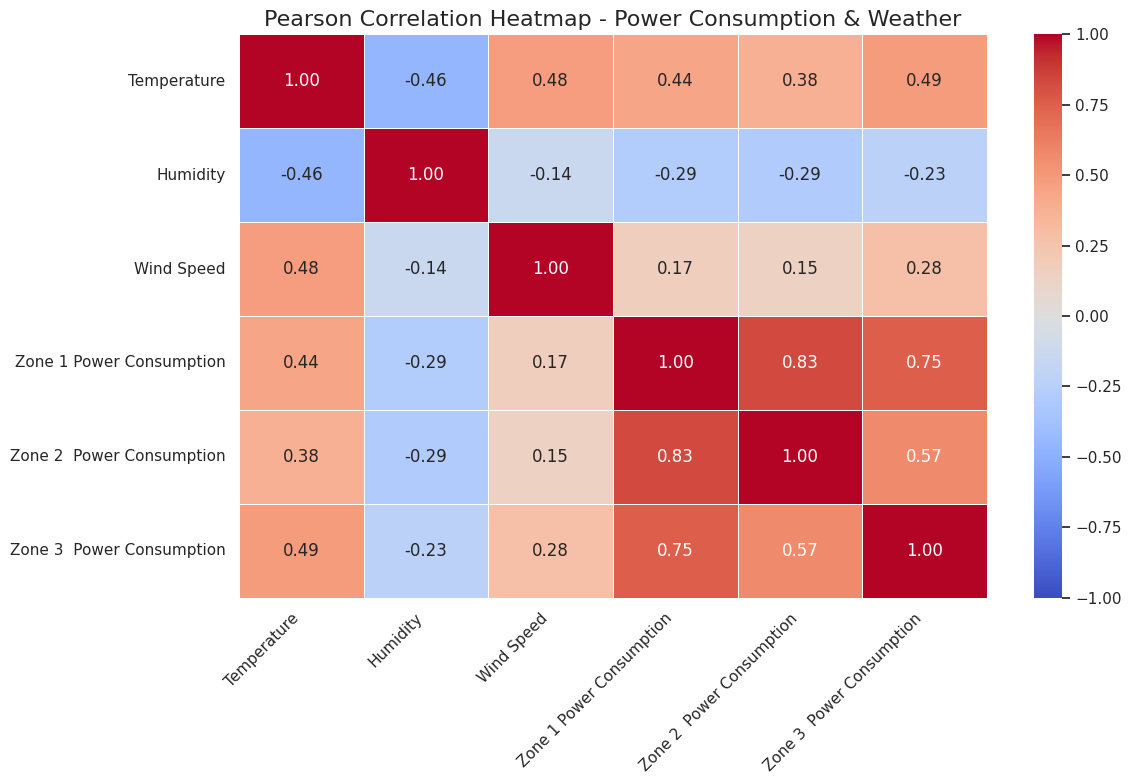

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 6.1 קורלציות בין משתנים מספריים ---")

# נתמקד במשתנים הרציפים בלבד
numeric_vars = ['Temperature', 'Humidity', 'Wind Speed', 'Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption']
df_numeric = df[numeric_vars]

# חישוב 3 סוגי הקורלציות
corr_pearson = df_numeric.corr(method='pearson')
corr_spearman = df_numeric.corr(method='spearman')
corr_kendall = df_numeric.corr(method='kendall')

# ציור מפת חום (Heatmap) עבור קורלציית פירסון
plt.figure(figsize=(12, 8))
sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, fmt='.2f', linewidths=0.5)
plt.title('Pearson Correlation Heatmap - Power Consumption & Weather', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# שמירת הגרף
plt.savefig('correlation_heatmap.png')
plt.show()

<div dir="rtl">

## 6. קורלציות וקשרים

### 6.1 מספרי-מספרי
**הסבר על ההבדל בין שיטות הקורלציה:**
* **פירסון (Pearson):** מודד קשר **ליניארי** בלבד בין שני משתנים (כמה הם מתנהגים כמו קו ישר). הוא רגיש לחריגים ומניח שהנתונים מתפלגים נורמלית.
* **ספירמן (Spearman):** מודד קשר **מונוטוני** (האם כשאחד עולה, השני גם עולה, לא בהכרח בקו ישר). הוא מבוסס על דירוג (Ranks) ולכן כמעט ולא מושפע מערכים חריגים (Outliers).
* **קנדל (Kendall):** דומה לספירמן (מבוסס דירוג לקשר מונוטוני), אך מתמקד בספירת זוגות תואמים לעומת לא-תואמים. הוא נחשב למדויק וחסון יותר מספירמן כאשר יש מדגמים קטנים או הרבה ערכים זהים (Ties), אך החישוב שלו איטי יותר. במדגם הענק שלנו (מעל 52 אלף שורות), ספירמן עדיף מבחינת ביצועים.

**תובנות ממפת החום (פירסון):**
* קיים מתאם חיובי וחזק מאוד בין אזורי הצריכה השונים (למשל סביב 0.83 בין אזור 1 לאזור 2). זה הגיוני – כשיש עומס חום או קור בעיר, רוב האזורים צורכים חשמל במקביל.
* קיים קשר שלילי (הפוך) חלש-בינוני בין לחות (Humidity) לטמפרטורה.
* נראה שהקשר הליניארי הישיר בין המדדים המטאורולוגיים (רוח, לחות, טמפרטורה) לצריכת החשמל אינו חזק מאוד (ערכי פירסון נמוכים מ-0.5), מה שמרמז שאולי הקשר מורכב יותר (לא ליניארי) או תלוי בשעה ביום ובחודש.

</div>

--- 6.2 קטגוריאלי ויצירת בינינג (Binning) ---
קשר בין חודש לקטגוריית טמפרטורה:


Temp_Category,Cold,Comfortable,Hot
Month,,,
1,3592,872,0
2,3630,402,0
3,3112,1051,301
4,1975,2008,337
5,212,2918,1334
6,26,1853,2441
7,0,153,4311
8,0,292,4172
9,29,1498,2793



--- 6.3 יצירת כל הגרפים הנדרשים ---


/tmp/ipykernel_12743/2034535096.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='Zone 1 Power Consumption', data=df, ax=axes[1,0], palette='viridis')
/tmp/ipykernel_12743/2034535096.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Is_Weekend', y='Zone 1 Power Consumption', data=df, ax=axes[1,1], palette='Set2')
/tmp/ipykernel_12743/2034535096.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Temp_Category', y='Zone 1 Power Consumption', data=df, ax=axes[2,0], palette='magma')


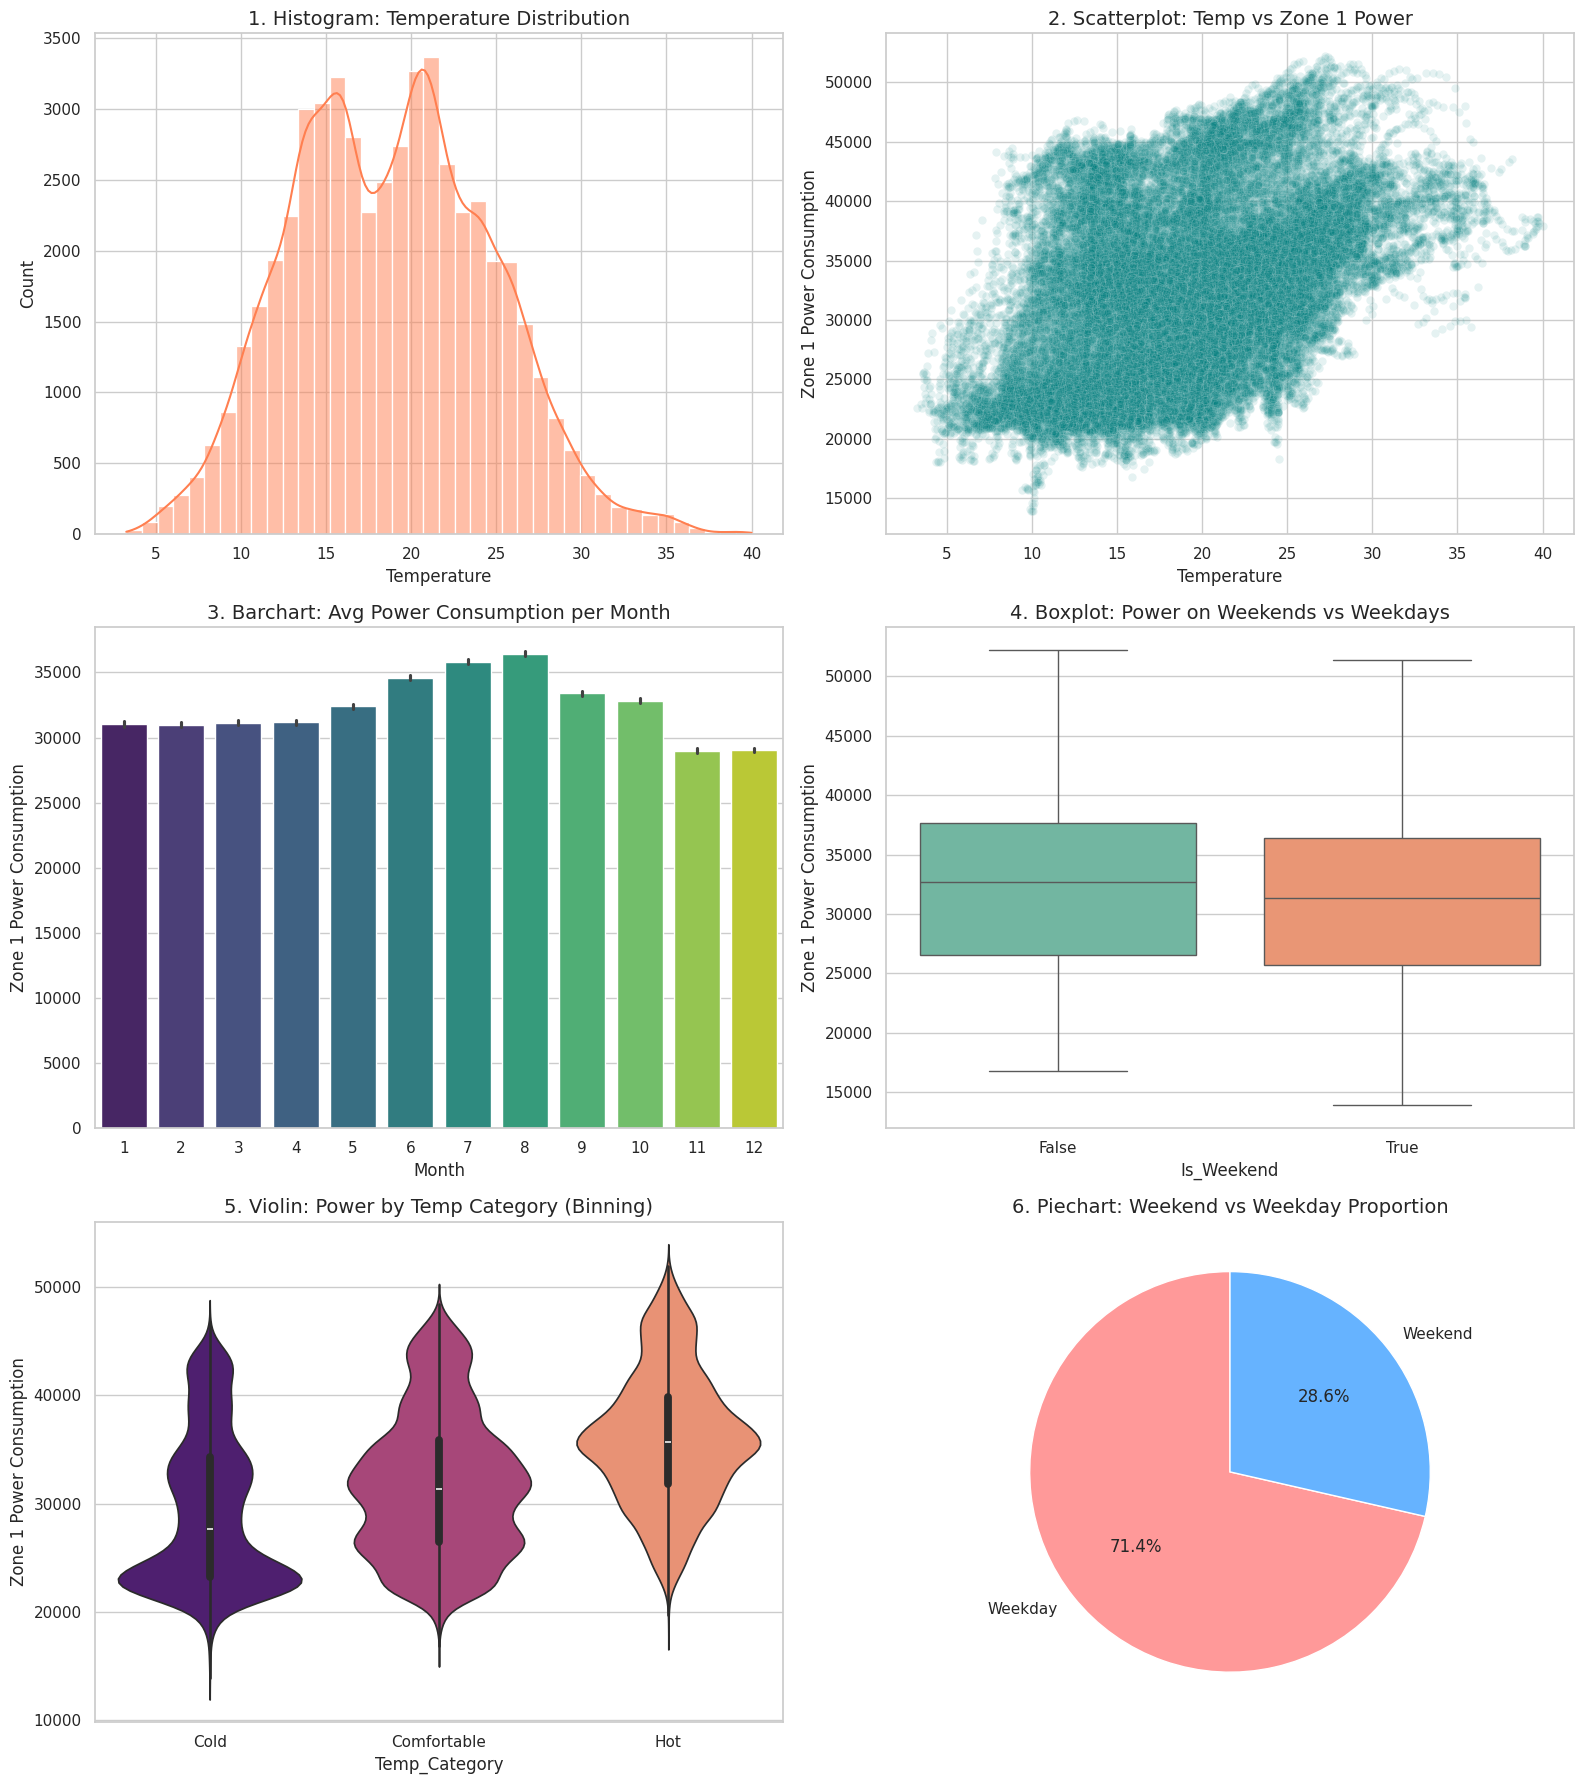


--- 7. Pairplot (על מדגם של 1000 שורות) ---


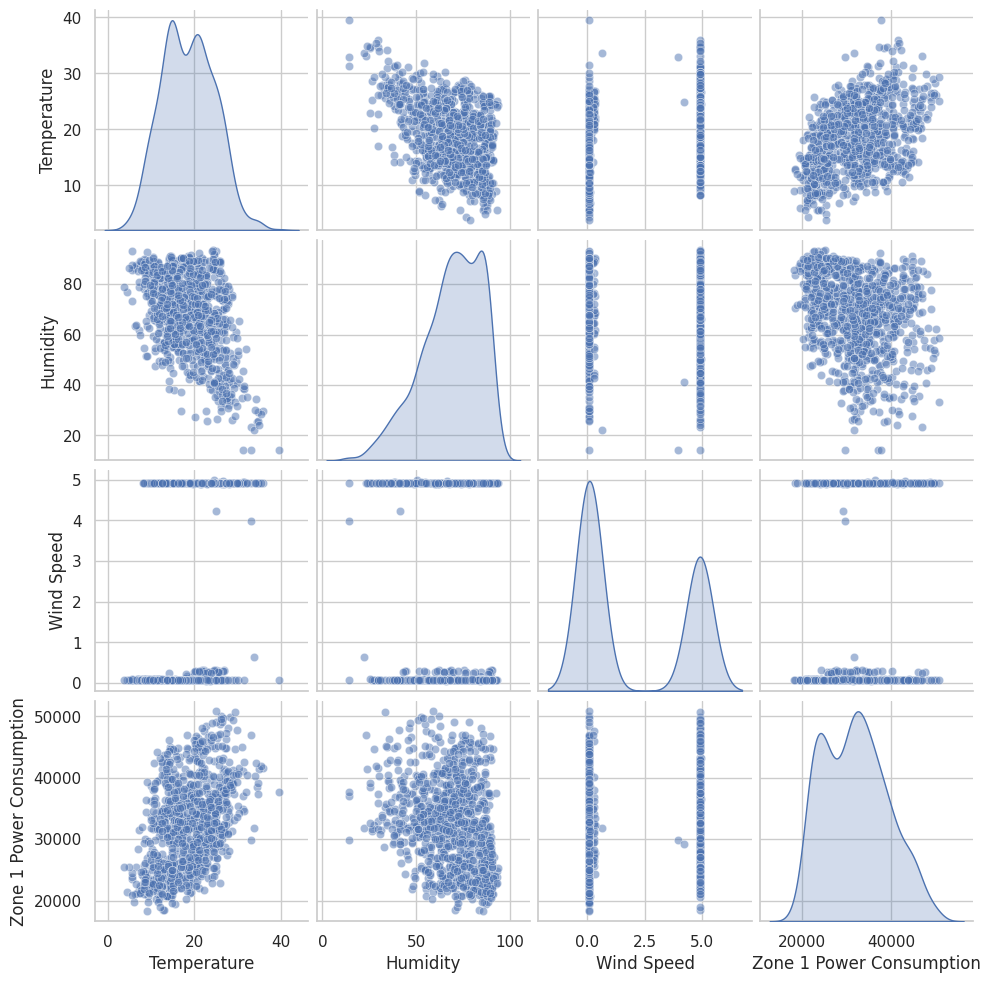

In [ ]:
print("--- 6.2 קטגוריאלי ויצירת בינינג (Binning) ---")
# יצירת קטגוריות לטמפרטורה (Binning) לחלק ל-3 קבוצות שוות
df['Temp_Category'] = pd.qcut(df['Temperature'], q=3, labels=['Cold', 'Comfortable', 'Hot'])

# יצירת טבלת שכיחויות (Crosstab) שבודקת את הקשר בין החודש לטמפרטורה
crosstab_result = pd.crosstab(df['Month'], df['Temp_Category'])
print("קשר בין חודש לקטגוריית טמפרטורה:")
display(crosstab_result)

print("\n--- 6.3 יצירת כל הגרפים הנדרשים ---")
# הגדרת לוח הציור - 3 שורות על 2 עמודות לגרפים
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
sns.set_theme(style="whitegrid")

# 1. Histogram (התפלגות הטמפרטורה)
sns.histplot(df['Temperature'], bins=40, ax=axes[0,0], color='coral', kde=True)
axes[0,0].set_title('1. Histogram: Temperature Distribution', fontsize=14)

# 2. Scatterplot (קשר בין טמפרטורה לצריכת חשמל)
sns.scatterplot(x='Temperature', y='Zone 1 Power Consumption', data=df, ax=axes[0,1], alpha=0.1, color='teal')
axes[0,1].set_title('2. Scatterplot: Temp vs Zone 1 Power', fontsize=14)

# 3. Barchart (ממוצע צריכת חשמל לפי חודש)
sns.barplot(x='Month', y='Zone 1 Power Consumption', data=df, ax=axes[1,0], palette='viridis')
axes[1,0].set_title('3. Barchart: Avg Power Consumption per Month', fontsize=14)

# 4. Boxplot (הבדלי צריכה בין ימי חול לסופ"ש)
sns.boxplot(x='Is_Weekend', y='Zone 1 Power Consumption', data=df, ax=axes[1,1], palette='Set2')
axes[1,1].set_title('4. Boxplot: Power on Weekends vs Weekdays', fontsize=14)

# 5. Violin plot (פיזור הצריכה לפי קטגוריות הטמפרטורה שיצרנו)
sns.violinplot(x='Temp_Category', y='Zone 1 Power Consumption', data=df, ax=axes[2,0], palette='magma')
axes[2,0].set_title('5. Violin: Power by Temp Category (Binning)', fontsize=14)

# 6. Piechart (התפלגות ימי חול מול סופ"ש)
axes[2,1].pie(df['Is_Weekend'].value_counts(), labels=['Weekday', 'Weekend'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
axes[2,1].set_title('6. Piechart: Weekend vs Weekday Proportion', fontsize=14)

plt.tight_layout()
plt.show()

# 7. Pairplot
print("\n--- 7. Pairplot (על מדגם של 1000 שורות) ---")
sample_df = df[['Temperature', 'Humidity', 'Wind Speed', 'Zone 1 Power Consumption']].sample(1000, random_state=42)
sns.pairplot(sample_df, kind='scatter', diag_kind='kde', plot_kws={'alpha':0.5})
plt.show()

<div dir="rtl">

### 6.2 קשרים קטגוריאליים (Binning)
* במסגרת ניתוח זה ביצענו תהליך של Binning (חלוקה לסלים) למשתנה הטמפרטורה הרציף, וחילקנו אותו ל-3 קטגוריות שוות: 'קר', 'נעים' ו-'חם' (Cold, Comfortable, Hot).
* **תובנה מטבלת השכיחויות (Crosstab):** בהצלבת קטגוריות אלו עם עמודת החודשים, ניתן לראות בבירור את חילופי העונות. חודשי הקיץ מתקבצים תחת קטגוריית "חם", בעוד חודשי החורף תופסים את קטגוריית "קר". הקשר הקטגוריאלי הזה מאשר שהנתונים אמינים ומשקפים נאמנה את אקלים העיר לאורך השנה.

### 6.3 תובנות מהגרפים
על מנת להעמיק את הבנת הנתונים, יצרנו מערך ויזואליזציות מקיף:
* **היסטוגרמה (Temperature):** צורת ההתפלגות של הטמפרטורה מזכירה פעמון (נורמלית) אך עם שתי פסגות (Bimodal). הדבר מרמז על הבדלים מובנים בדאטה, כגון ההפרש הקבוע בין טמפרטורות יום לטמפרטורות לילה.
* **גרף פיזור (Scatterplot):** הקשר בין טמפרטורה לצריכת חשמל (Zone 1) מציג מגמה כללית של עלייה בצריכה ככל שהטמפרטורה מטפסת, סביר להניח עקב הפעלת מערכות מיזוג אוויר.
* **גרף עמודות (Barchart):** ממחיש בצורה ברורה עונתיות בצריכת החשמל. החודשים החמים של השנה מציגים את ממוצע הצריכה הגבוה ביותר באופן מובהק.
* **גרף קופסה (Boxplot):** השוואת צריכת החשמל מציגה חציון צריכה גבוה יותר ופיזור נרחב יותר בימי חול (Weekday) לעומת סופי שבוע (Weekend). ניתן להסיק מכך שפעילות תעשייתית ומסחרית תורמת משמעותית לעומס על הרשת באמצע השבוע.
* **גרף כינור (Violin Plot):** משלב בצורה חכמה את ה-Binning שלנו. ניתן לראות שבקטגוריית מזג האוויר ה"חם" (Hot), התפלגות צריכת החשמל רחבה יותר בחלקה העליון – עדות לכך שקיצון מטאורולוגי מושך את הרשת למאמץ גבוה יותר.
* **Pairplot:** גרף מטריצת הפיזור (שבוצע על מדגם כדי למנוע עומס חישובי) מספק אימות ויזואלי לתוצאות קורלציית פירסון ממפת החום, כגון הקשר השלילי שמוצג כענן יורד בין לחות לטמפרטורה.

</div>

In [ ]:
print("--- 7. בדיקות אינדקס ---")
print(f"Is index unique? {df.index.is_unique}")
print(f"Is index sorted (monotonic increasing)? {df.index.is_monotonic_increasing}")
print(f"Is DateTime column sorted? {df['DateTime'].is_monotonic_increasing}")

--- 7. בדיקות אינדקס ---
Is index unique? True
Is index sorted (monotonic increasing)? True
Is DateTime column sorted? True


<div dir="rtl">

## 7. ניתוח אינדקס

* **האם האינדקס ייחודי?** כן. האינדקס הנוכחי הוא `RangeIndex` המקצה מספר ייחודי מ-0 ועד 52,415 לכל שורה.
* **האם מבוסס זמן?** האינדקס המספרי עצמו אינו מבוסס זמן, אך עמודת ה-`DateTime` מהווה את "האינדקס הלוגי" והמהותי של מערך הנתונים, שכן כל רשומה מייצגת מדידה בנקודת זמן ספציפית (כל 10 דקות).
* **האם ממוין?** כן, בדיקה בקוד (is_monotonic_increasing) מאשרת שגם האינדקס המספרי וגם עמודת ה-DateTime ממוינים בסדר כרונולוגי עולה.
* **האם הניתוח משתנה בזמן?** בהחלט. כפי שראינו בגרפים העונתיים (Barchart) ובגרפי הפיזור, צריכת החשמל והמדדים המטאורולוגיים משתנים באופן דרמטי כתלות בחודש בשנה (עונתיות) וביום בשבוע (ימי חול מול סופ"ש).

</div>

<div dir="rtl">

## 8. תובנות וסיפור הנתונים

**סיכום מנהלים:**
מערך הנתונים הציג תמונה אמינה, נקייה מרעשים (ללא ערכים חסרים או כפילויות) ורציפה של צריכת חשמל בעיר טטואן. הוספת משתני זמן (Feature Engineering) אפשרה לנו להפוך נתונים "שטוחים" לתובנות מבוססות עונתיות ומחזוריות אנושית.

**3 תובנות מרכזיות:**
1. **אפקט הסופ"ש:** קיימת צניחה מובהקת בצריכת החשמל בסופי שבוע לעומת ימי חול. הדבר מצביע על כך שהעומס המרכזי על הרשת נובע ממגזרים תעשייתיים, מסחריים או מוסדיים שאינם פעילים במלוא המרץ בסופ"ש, ולא מצריכה ביתית רגילה.
2. **מתאם גבוה בין אזורים (Zones):** גילינו קורלציה חיובית חזקה (מעל 0.75) בין אזורי הצריכה השונים בעיר. משמעות הדבר היא שגורמי המאקרו (כמו עומס חום או שעות האור) משפיעים על העיר כולה כגוף אחד, וקשה למצוא אזור ש"מאזן" אזור אחר.
3. **אשליה סטטיסטית במשתנים עם שונות נמוכה:** בניתוח החד-משתני חווינו הדגמה חיה לכך שאלגוריתמים עוורים עלולים לטעות. בעוד שמשתנה כיוון הרוח כמעט ולא הציג חריגים בשיטות סטנדרטיות (Z-score, IQR), שיטת MAD סימנה כמעט מחצית מהנתונים כחריגים. התובנה היא שלעולם אין להסתמך על מתמטיקה עיוורת ללא הבנת פיזור הדאטה.

**הטיות וסיכונים (נקודות כשל למודלי ML):**
* **הטיית חגים/אירועים:** הוספנו משתנה בוליאני של `Is_Weekend`. מודל ML שיתבסס רק על המשתנה הזה ייכשל בחיזוי העומס בימי חג (שנופלים באמצע השבוע) או באירועי קיצון (כמו סגר, מלחמה או אירוע ספורט משמעותי), מכיוון שהדאטה לא מספק קונטקסט לאומי אלא רק קלנדרי.
* **הטיית שינויי אקלים:** הנתונים נאספו בשנה ספציפית. מודל למידת מכונה שיתאמן על הטמפרטורות הללו בלבד (Data Drift) עלול לבצע הערכת-חסר חמורה בשנים חמות יותר בעקבות התחממות גלובלית, מה שיגרום לקריסת רשת החשמל בשל תחזית שגויה.

**למידה אישית:**
בתהליך הניתוח למדתי עד כמה חשוב שלב ה-Feature Engineering והוויזואליזציה. מהסתכלות יבשה על טבלת מספרים קשה מאוד להבין את הקשר המורכב בין לחות לטמפרטורה, אך מפת החום (Heatmap) וגרפי הפיזור (Pairplot) הפכו את הקשרים הסמויים הללו לברורים ומיידיים. הבנתי שאיכות הנתונים (כפי שראינו עם 0 נתונים חסרים) חוסכת זמן רב, אך מחייבת אותנו להיות חשדניים יותר לגבי האופן שבו הם טופלו במקור.

</div>